In [66]:
from kan import *
import torch
torch.cuda.empty_cache()
from sklearn.metrics import mean_absolute_error
import os

In [67]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu" )
print(device)

cuda:3


In [68]:
mit_data = torch.load('../Data/MIT_Data_Var4.pt')

# If the .pt file contains a tensor, you can directly use it
print(mit_data)

{'train_input': tensor([[-0.8107,  0.9373,  0.8139, -1.0000],
        [-0.8997,  0.9582,  0.8903, -0.9970],
        [-0.8993,  0.9582,  0.8809, -0.9941],
        ...,
        [ 0.9302, -0.9676, -0.9173,  0.9948],
        [ 0.9721, -0.9678, -0.9474,  0.9966],
        [ 1.0000, -1.0000, -1.0000,  1.0000]], device='cuda:3'), 'train_label': tensor([[0.9944],
        [0.9951],
        [0.9956],
        ...,
        [0.8754],
        [0.8748],
        [0.8737]], device='cuda:3'), 'test_input': tensor([[-0.9232,  0.9417,  0.8930, -1.0000],
        [-0.9464,  0.9417,  0.9087, -0.9950],
        [-0.9126,  0.9417,  0.9385, -0.9900],
        ...,
        [ 0.9663, -0.9683, -0.9483,  0.9957],
        [ 0.9609, -0.9999, -0.9929,  0.9978],
        [ 1.0000, -1.0000, -1.0000,  1.0000]], device='cuda:3'), 'test_label': tensor([[0.9873],
        [0.9880],
        [0.9884],
        ...,
        [0.8880],
        [0.8873],
        [0.8866]], device='cuda:3'), 'train_diff_input': tensor([[-0.8107,  0.9373

/tmp/ipykernel_1351296/1091693599.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mit_data = torch.load('../Data/MIT_Data_Var4.pt')


In [69]:
mit_dataset = {
        'train_input': mit_data['train_input'],
        'train_label': mit_data['train_label'],
        'test_input': mit_data['test_input'],
        'test_label': mit_data['test_label']
    }
mit_dataset_cpu = {
        'train_input': mit_data['train_input'].to('cpu'),
        'train_label': mit_data['train_label'].to('cpu'),
        'test_input': mit_data['test_input'].to('cpu'),
        'test_label': mit_data['test_label'].to('cpu')
    }

In [70]:
kan_mit = KAN(width=[4,5,1], grid=3, k=3, seed=25, ckpt_path='../Notebooks/ckpt_path/kan_mit',device=device)

checkpoint directory created: ../Notebooks/ckpt_path/kan_mit
saving model version 0.0


In [ ]:
# def train_mse():
#     with torch.no_grad():
#         predictions = kan_mit(mit_dataset['train_input'])
#         mse = torch.nn.functional.mse_loss(predictions, mit_dataset['train_label'])
#     return mse

# def test_mse():
#     with torch.no_grad():
#         predictions = kan_mit(mit_dataset['test_input'])
#         mse = torch.nn.functional.mse_loss(predictions, mit_dataset['test_label'])
#     return mse

In [71]:
results = kan_mit.fit(
    mit_dataset,
    opt="LBFGS",
    loss_fn=torch.nn.MSELoss(),  # Change loss function to MSE
    steps=50,
    lamb=0.0001,
    save_fig=True,
    img_folder='../Images/kan_mit/video_img_f1'
)

description:   0%|                                                           | 0/50 [00:00<?, ?it/s]

| train_loss: 1.22e-02 | test_loss: 1.22e-02 | reg: 1.91e+00 | : 100%|█| 50/50 [19:44<00:00, 23.68s/

saving model version 0.1


image saved at ../Images/kan_mit/paper_img/train_and_test_loss.png


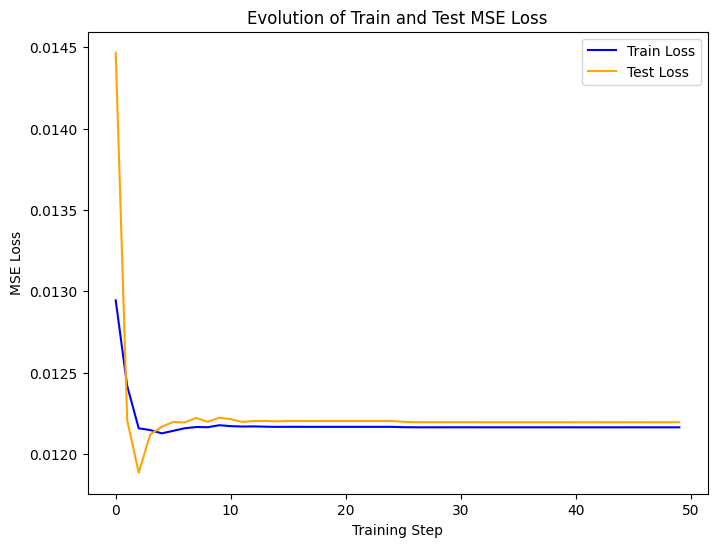

In [ ]:
import matplotlib.pyplot as plt
# Assuming results['train_mse'] and results['test_mse'] are lists of MSE values for each training step
train_losses = results['train_loss']
test_losses = results['test_loss']
# Plot the evolution of train and test loss
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(test_losses, label="Test Loss", color="orange")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.title("Evolution of Train and Test MSE Loss")
plt.legend()
# Save the plot to a specific location
save_path = '../Images/kan_mit/paper_img/train_and_test_loss_f1.png'  # Change this path as needed
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
print("image saved at "+save_path)
plt.show()

/data/huangjh/anaconda/envs/pikan/lib/python3.10/site-packages/kan/MultKAN.py:571: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(f'{path}_state')
/data/hu

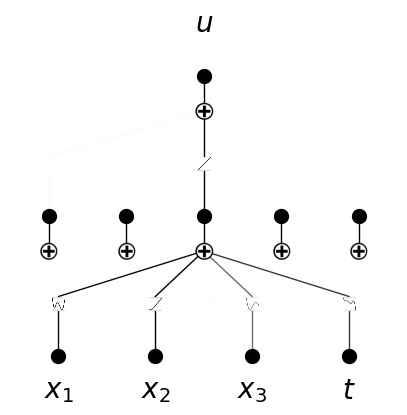

In [82]:
kan_mit = KAN.loadckpt('../Notebooks/ckpt_path/kan_mit/0.1')
kan_mit.plot(folder="../Images/kan_mit/paper_img/kan_f1/full_png",beta=50,in_vars=[r'$x_1$', r'$x_2$',r'$x_3$',r'$t$'], out_vars=[r'$u$'])

In [84]:
kan_mit = kan_mit.prune(node_th=0.001, edge_th=0.003)

saving model version 1.2


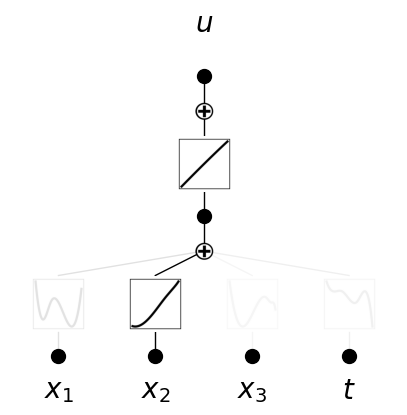

In [85]:
kan_mit.plot(folder="../Images/kan_mit/paper_img/kan_p1/full_png", in_vars=[r'$x_1$', r'$x_2$',r'$x_3$',r'$t$'], out_vars=[r'$u$'])

In [86]:
results = kan_mit.fit(
    dataset=mit_dataset,
    opt="LBFGS",    #LBFGS
    loss_fn=torch.nn.MSELoss(),  # Change loss function to MSE
    steps=50,
    save_fig=True,
    img_folder='../Images/kan_mit/video_img_f2'
)

| train_loss: 1.10e-02 | test_loss: 1.13e-02 | reg: 3.55e+00 | : 100%|█| 50/50 [04:29<00:00,  5.38s/

saving model version 1.3


image saved at ../Images/kan_mit/paper_img/train_and_test_loss_f2.png


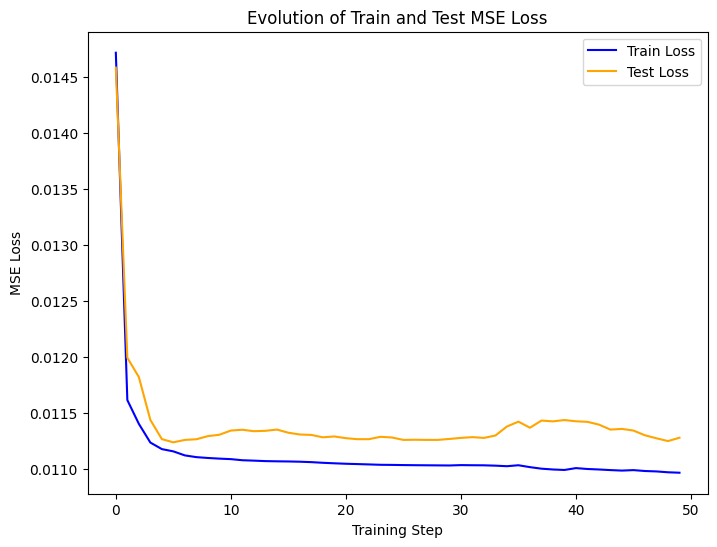

In [87]:
import matplotlib.pyplot as plt
# Assuming results['train_mse'] and results['test_mse'] are lists of MSE values for each training step
train_losses = results['train_loss']
test_losses = results['test_loss']
# Plot the evolution of train and test loss
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(test_losses, label="Test Loss", color="orange")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.title("Evolution of Train and Test MSE Loss")
plt.legend()
# Save the plot to a specific location
save_path = '../Images/kan_mit/paper_img/train_and_test_loss_f2.png'  # Change this path as needed
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
print("image saved at "+save_path)
plt.show()

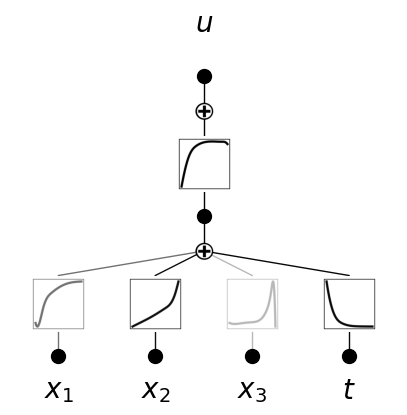

In [88]:
kan_mit.plot(folder="../Images/kan_mit/paper_img/kan_f2/full_png", in_vars=[r'$x_1$', r'$x_2$',r'$x_3$',r'$t$'], out_vars=[r'$u$'])

In [89]:
add_symbolic('sigmoid', torch.sigmoid)
add_symbolic('relu',torch.relu)
add_symbolic('cosh',torch.cosh)
add_symbolic('sinh',torch.sinh)
kan_mit = kan_mit.to('cuda:1')
mit_dataset_cuda = {
        'train_input': mit_data['train_input'].to('cuda:1'),
        'train_label': mit_data['train_label'].to('cuda:1'),
        'test_input': mit_data['test_input'].to('cuda:1'),
        'test_label': mit_data['test_label'].to('cuda:1')
    }
kan_mit.get_act(mit_dataset_cuda)
print(kan_mit.suggest_symbolic(0,0,0))
print(kan_mit.suggest_symbolic(0,1,0))
print(kan_mit.suggest_symbolic(0,2,0))
print(kan_mit.suggest_symbolic(0,3,0))
print(kan_mit.suggest_symbolic(1,0,0))

  function  fitting r2   r2 loss  complexity  complexity loss  total loss
0  sigmoid    0.986320 -6.190767           1                1   -0.438153
1     cosh    0.977541 -5.475918           1                1   -0.295184
2     sinh    0.976826 -5.430709           1                1   -0.286142
3     relu    0.964725 -4.824792           1                1   -0.164958
4        0    0.000000  0.000014           0                0    0.000003
('sigmoid', (<built-in method sigmoid of type object at 0x7dccdd8bf1c0>, sigmoid, 1, <built-in method sigmoid of type object at 0x7dccdd8bf1c0>), 0.9863203167915344, 1)
  function  fitting r2   r2 loss  complexity  complexity loss  total loss
0     sinh    0.995791 -7.889032           1                1   -0.777806
1     cosh    0.985825 -6.139496           1                1   -0.427899
2  sigmoid    0.985769 -6.133851           1                1   -0.426770
3      log    0.996915 -8.336031           2                2   -0.067206
4        0    0.0

In [91]:
kan_mit = kan_mit.to(device)
kan_mit.get_act(mit_dataset)
kan_mit = kan_mit.prune()

saving model version 1.4


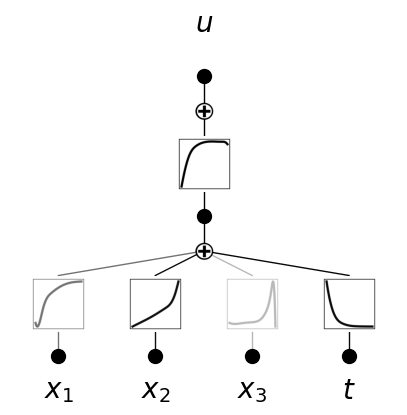

In [92]:
kan_mit.plot(folder="../Images/kan_mit/paper_img/kan_p2/full_png", in_vars=[r'$x_1$', r'$x_2$',r'$x_3$',r'$t$'], out_vars=[r'$u$'])

In [93]:
results = kan_mit.fit(
    dataset=mit_dataset,
    opt="LBFGS",    
    loss_fn=torch.nn.MSELoss(),  # Change loss function to MSE
    steps=50,
    save_fig=True,
    img_folder='../Images/kan_mit/video_img_f3'
)

| train_loss: 1.09e-02 | test_loss: 1.13e-02 | reg: 3.90e+00 | : 100%|█| 50/50 [06:34<00:00,  7.89s/

saving model version 1.5


image saved at ../Images/kan_mit/paper_img/train_and_test_loss_f3.png


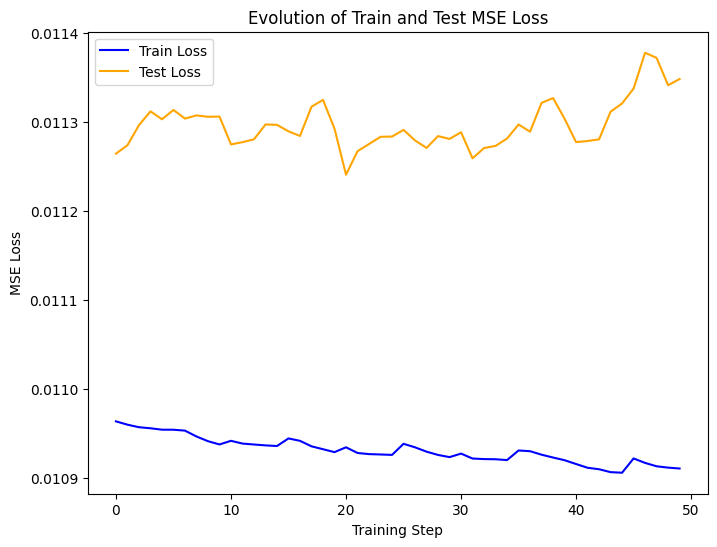

In [94]:
import matplotlib.pyplot as plt
# Assuming results['train_mse'] and results['test_mse'] are lists of MSE values for each training step
train_losses = results['train_loss']
test_losses = results['test_loss']
# Plot the evolution of train and test loss
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(test_losses, label="Test Loss", color="orange")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.title("Evolution of Train and Test MSE Loss")
plt.legend()
# Save the plot to a specific location
save_path = '../Images/kan_mit/paper_img/train_and_test_loss_f3.png'  # Change this path as needed
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
print("image saved at "+save_path)
plt.show()

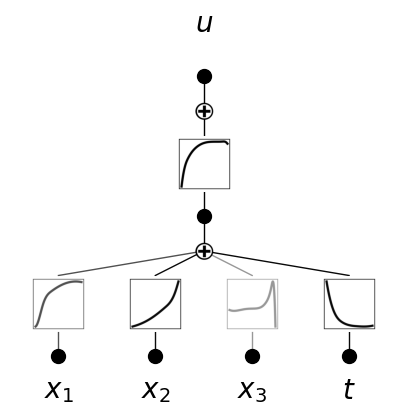

In [95]:
kan_mit.plot(folder="../Images/kan_mit/paper_img/kan_f3/full_png", in_vars=[r'$x_1$', r'$x_2$',r'$x_3$',r'$t$'], out_vars=[r'$u$'])

In [97]:
add_symbolic('sigmoid', torch.sigmoid)
add_symbolic('relu',torch.relu)
add_symbolic('cosh',torch.cosh)
add_symbolic('sinh',torch.sinh)
add_symbolic('arcsinh',torch.arcsinh)
add_symbolic('arccosh',torch.arccosh)
kan_mit = kan_mit.to('cuda:1')
mit_dataset_cuda = {
        'train_input': mit_data['train_input'].to('cuda:1'),
        'train_label': mit_data['train_label'].to('cuda:1'),
        'test_input': mit_data['test_input'].to('cuda:1'),
        'test_label': mit_data['test_label'].to('cuda:1')
    }
kan_mit.get_act(mit_dataset_cuda)
print(kan_mit.suggest_symbolic(0,0,0))
print(kan_mit.suggest_symbolic(0,1,0))
print(kan_mit.suggest_symbolic(0,2,0))
print(kan_mit.suggest_symbolic(0,3,0))
print(kan_mit.suggest_symbolic(1,0,0))

  function  fitting r2    r2 loss  complexity  complexity loss  total loss
0  arcsinh    0.999042 -10.013289           1                1   -1.202658
1  sigmoid    0.994139  -7.412182           1                1   -0.682436
2     cosh    0.992629  -7.081955           1                1   -0.616391
3     sinh    0.992623  -7.080813           1                1   -0.616163
4  arccosh    0.966807  -4.912533           1                1   -0.182507
('arcsinh', (<built-in method arcsinh of type object at 0x7dccdd8bf1c0>, arcsinh, 1, <built-in method arcsinh of type object at 0x7dccdd8bf1c0>), 0.9990423917770386, 1)
  function  fitting r2    r2 loss  complexity  complexity loss  total loss
0  arccosh    0.999119 -10.132647           1                1   -1.226529
1  arcsinh    0.999082 -10.073910           1                1   -1.214782
2     sinh    0.997166  -8.457761           1                1   -0.891552
3     cosh    0.993193  -7.196578           1                1   -0.639316
4  sig

In [98]:
kan_mit = kan_mit.to(device)
results = kan_mit.fit(
    dataset=mit_dataset,
    opt="LBFGS",    
    loss_fn=torch.nn.MSELoss(),  # Change loss function to MSE
    steps=50,
    save_fig=True,
    img_folder='../Images/kan_mit/video_img_f4'
)

| train_loss: 1.09e-02 | test_loss: 1.14e-02 | reg: 4.42e+00 | : 100%|█| 50/50 [06:18<00:00,  7.57s/

saving model version 1.6


image saved at ../Images/kan_mit/paper_img/train_and_test_loss_f4.png


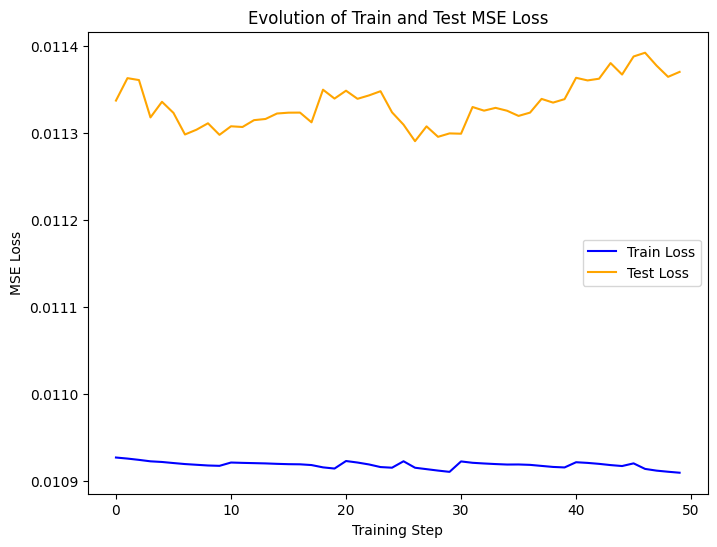

In [99]:
import matplotlib.pyplot as plt
# Assuming results['train_mse'] and results['test_mse'] are lists of MSE values for each training step
train_losses = results['train_loss']
test_losses = results['test_loss']
# Plot the evolution of train and test loss
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(test_losses, label="Test Loss", color="orange")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.title("Evolution of Train and Test MSE Loss")
plt.legend()
# Save the plot to a specific location
save_path = '../Images/kan_mit/paper_img/train_and_test_loss_f4.png'  # Change this path as needed
plt.savefig(save_path, format='png', dpi=300, bbox_inches='tight')
print("image saved at "+save_path)
plt.show()

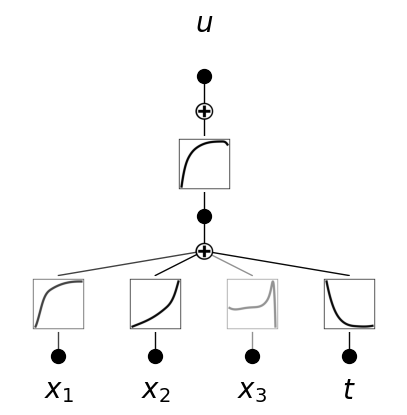

In [101]:
kan_mit.plot(folder="../Images/kan_mit/paper_img/kan_f4/full_png", in_vars=[r'$x_1$', r'$x_2$',r'$x_3$',r'$t$'], out_vars=[r'$u$'])

In [102]:
add_symbolic('sigmoid', torch.sigmoid)
add_symbolic('relu',torch.relu)
add_symbolic('cosh',torch.cosh)
add_symbolic('sinh',torch.sinh)
add_symbolic('arcsinh',torch.arcsinh)
add_symbolic('arccosh',torch.arccosh)
kan_mit = kan_mit.to('cuda:1')
mit_dataset_cuda = {
        'train_input': mit_data['train_input'].to('cuda:1'),
        'train_label': mit_data['train_label'].to('cuda:1'),
        'test_input': mit_data['test_input'].to('cuda:1'),
        'test_label': mit_data['test_label'].to('cuda:1')
    }
kan_mit.get_act(mit_dataset_cuda)
print(kan_mit.suggest_symbolic(0,0,0))
print(kan_mit.suggest_symbolic(0,1,0))
print(kan_mit.suggest_symbolic(0,2,0))
print(kan_mit.suggest_symbolic(0,3,0))
print(kan_mit.suggest_symbolic(1,0,0))

  function  fitting r2   r2 loss  complexity  complexity loss  total loss
0  sigmoid    0.996335 -8.087935           1                1   -0.817587
1  arcsinh    0.995137 -7.681020           1                1   -0.736204
2     sinh    0.994847 -7.597541           1                1   -0.719508
3     cosh    0.994824 -7.591226           1                1   -0.718245
4     relu    0.968843 -5.003842           1                1   -0.200768
('sigmoid', (<built-in method sigmoid of type object at 0x7dccdd8bf1c0>, sigmoid, 1, <built-in method sigmoid of type object at 0x7dccdd8bf1c0>), 0.9963347315788269, 1)
  function  fitting r2    r2 loss  complexity  complexity loss  total loss
0  arcsinh    0.999412 -10.707280           1                1   -1.341456
1  arccosh    0.998713  -9.590823           1                1   -1.118165
2     sinh    0.997977  -8.942356           1                1   -0.988471
3     cosh    0.993627  -7.291579           1                1   -0.658316
4  sigmoid  

以上符号化失败

In [103]:
import gc
torch.cuda.empty_cache()
gc.collect()

1454221